# 00 — EDA: the user–artist interaction matrix

> **Phase 1 (Last.fm-2k).** Notebooks 00–07 build and stress-test the methodology on the small HetRec-2011 set. That data caps every user at their top-50 artists, which makes it a clean sandbox but an artificial task with depressed scores. In **Phase 2** the project scales to the real, uncapped **Last.fm-360K** data and promotes **EASE** as the served model — see [`notebooks/08`](08_scaling_to_360k.ipynb). These Phase-1 notebooks are the methodology record; their committed outputs are the 2k analysis and are not meant to be re-run against the now-360K split.

**Milestone 1.** Load Last.fm (HetRec 2011), build the user–artist interaction matrix, and quantify two things that decide the rest of the project:

1. **Sparsity** — what fraction of the matrix is zero.
2. **Interaction distribution** — per user and per artist, with attention to the thin tail (which sizes cold-start) and the variance it implies for evaluation.

This is the recsys analog of checking FPD's class balance before designing the search. The honest write-up of whether sparsity here demands FPD's stability machinery is in [`docs/specs/sparsity_fragility_investigation.md`](../docs/specs/sparsity_fragility_investigation.md).

All pipeline logic lives in `src/data_loading.py`; this notebook just calls it and narrates.

In [1]:
import sys
from pathlib import Path
# Make src/ importable when running from notebooks/. No chdir needed: src.utils
# anchors all data paths to PROJECT_ROOT, so the working directory doesn't matter.
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
from src import data_loading as dl
from src import plotting as viz

viz.set_style()
FIG = project_root / 'outputs' / 'figures'  # anchored, so saving works from any cwd
df = dl.load_user_artists()
print(f'raw interaction rows: {len(df):,}')
print(f'duplicate (user,artist) pairs: {df.duplicated(["userID","artistID"]).sum()}')
df.head()

2026-06-30 18:24:50 | INFO    | data_loading | Loaded 92,834 interactions from user_artists.dat


raw interaction rows: 92,834
duplicate (user,artist) pairs: 0


,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


The signal is **`weight` = listening count** per (user, artist). No explicit ratings — this is **implicit feedback** (see [`docs/learning/why_implicit_feedback.md`](../docs/learning/why_implicit_feedback.md)), which is why we'll model with confidence-weighted ALS and evaluate with ranking metrics, not RMSE.

In [2]:
im = dl.build_interaction_matrix(df)
rep = dl.sparsity_report(im.matrix)
print(f"matrix shape: {rep['n_users']:,} users x {rep['n_items']:,} artists = {rep['n_cells']:,} cells")
print(f"interactions (nonzero): {rep['n_interactions']:,}")
print(f"density:  {rep['density']*100:.4f}%")
print(f"SPARSITY: {rep['sparsity_pct']:.2f}%  (fraction of the matrix that is zero)")

matrix shape: 1,892 users x 17,632 artists = 33,359,744 cells
interactions (nonzero): 92,834
density:  0.2783%
SPARSITY: 99.72%  (fraction of the matrix that is zero)


## Data quality — sanity checks before trusting anything

Before any modelling decision, confirm the data is clean: no nulls, no duplicate (user, artist) rows, positive weights, and that interaction IDs line up with the artist-name metadata.

In [3]:
print(f"nulls anywhere:            {int(df.isnull().sum().sum())}")
print(f"duplicate (user,artist):   {int(df.duplicated(['userID','artistID']).sum())}")
print(f"non-positive weights:      {int((df['weight'] <= 0).sum())}")
print(f"users:  {df['userID'].nunique():,}  (id range {df['userID'].min()}-{df['userID'].max()})")
print(f"artists:{df['artistID'].nunique():>7,}  (id range {df['artistID'].min()}-{df['artistID'].max()})")

artists_meta = dl.load_artists()
unnamed = set(df['artistID'].unique()) - set(artists_meta['id'])
print(f"artists in interactions with no name in artists.dat: {len(unnamed)}")
print("\nClean: no nulls, no dupes, all weights positive, IDs consistent. Safe to proceed.")

nulls anywhere:            0
duplicate (user,artist):   0
non-positive weights:      0
users:  1,892  (id range 2-2100)
artists: 17,632  (id range 1-18745)
artists in interactions with no name in artists.dat: 0

Clean: no nulls, no dupes, all weights positive, IDs consistent. Safe to proceed.


## Interactions per user — and the key structural fact

Watch the distribution carefully: it is **not** a smooth long tail.

In [4]:
upu = dl.interactions_per_user(im.matrix)
print(f'per-user interactions: min={upu.min()}, median={np.median(upu):.0f}, mean={upu.mean():.2f}, max={upu.max()}')
for t in (1, 2, 5, 10):
    print(f'  users with <= {t:>2} interactions: {(upu<=t).sum():>4}  ({(upu<=t).mean()*100:.1f}%)')
print(f'  users with exactly 50:        {(upu==50).sum():>4}  ({(upu==50).mean()*100:.1f}%)')

per-user interactions: min=1, median=50, mean=49.07, max=50
  users with <=  1 interactions:    8  (0.4%)
  users with <=  2 interactions:    9  (0.5%)
  users with <=  5 interactions:   16  (0.8%)
  users with <= 10 interactions:   21  (1.1%)
  users with exactly 50:        1829  (96.7%)


**Interactions per user are effectively capped at 50.** Median 50, mean ~49, max 50; ~97% of users sit exactly at 50. The GroupLens readme confirms it — "avg. 49.067 artists *most listened* by each user": the dataset is each user's **top-~50 artists** by construction.

Consequence: the 99.7% sparsity is **structural** (we truncated each user to 50 of 17,632 artists), not because users are data-poor. Every modeled user brings a full taste profile, so the per-user holdout split is well-conditioned on the user axis, and **user-side cold start is tiny** (only a handful of users are thin).

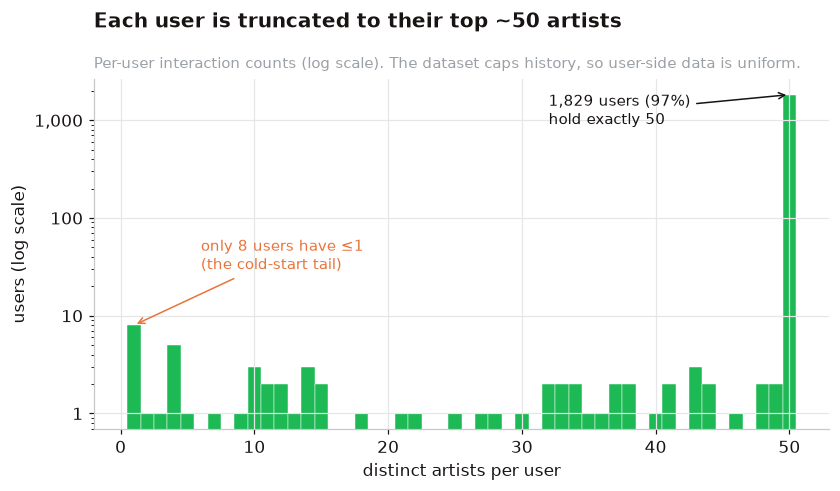

In [5]:
_ = viz.plot_interactions_per_user(upu, save_path=FIG / 'interactions_per_user.png')

## Interactions per artist — where the sparsity actually bites

In [6]:
ipi = dl.interactions_per_item(im.matrix)
print(f'listeners per artist: min={ipi.min()}, median={np.median(ipi):.0f}, mean={ipi.mean():.2f}, max={ipi.max()}')
for t in (1, 2, 5):
    print(f'  artists with <= {t} listener(s): {(ipi<=t).sum():>6,}  ({(ipi<=t).mean()*100:.1f}%)')

listeners per artist: min=1, median=1, mean=5.27, max=611
  artists with <= 1 listener(s): 10,679  (60.6%)
  artists with <= 2 listener(s): 13,018  (73.8%)
  artists with <= 5 listener(s): 15,215  (86.3%)


**This is the real sparsity story.** The median artist has a single listener; ~61% of artists have exactly one listener and ~74% have ≤2. A collaborative model has almost nothing to learn for these — they are near-unrecommendable and cap achievable recall. It also means a **popularity baseline** will be strong and is the honest reference point to beat.

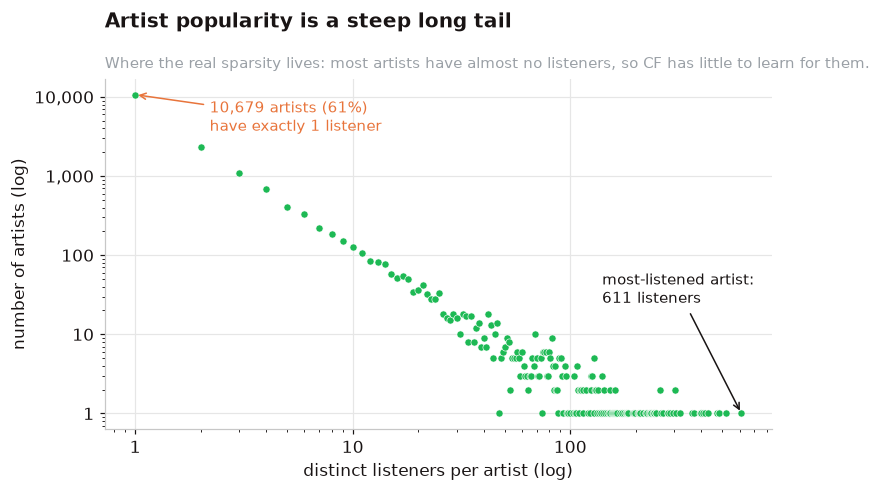

In [7]:
_ = viz.plot_artist_long_tail(ipi, save_path=FIG / 'artist_long_tail.png')

### How concentrated is listening? A Lorenz curve and Gini

"Long tail" is qualitative; let's quantify the inequality with a Lorenz curve and Gini coefficient (the same Gini we later report as a beyond-accuracy metric). This is *why* a popularity baseline is hard to beat and *why* catalog coverage is a real concern.

Gini of artist popularity by distinct listeners: 0.730
Gini of artist popularity by total plays:        0.893


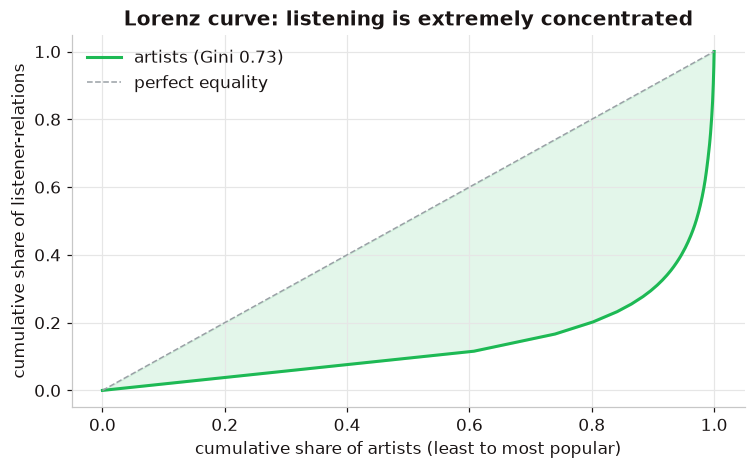


The top 1% of artists account for 32% of all listener-relations.


In [8]:
import matplotlib.pyplot as plt

def gini_coef(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    idx = np.arange(1, n + 1)
    return float(np.sum((2 * idx - n - 1) * x) / (n * x.sum()))

plays = np.asarray(im.matrix.sum(axis=0)).ravel()  # total plays per artist
print(f"Gini of artist popularity by distinct listeners: {gini_coef(ipi):.3f}")
print(f"Gini of artist popularity by total plays:        {gini_coef(plays):.3f}")

order = np.sort(ipi)
cum = np.cumsum(order) / order.sum()
xs = np.arange(1, len(order) + 1) / len(order)
fig, ax = plt.subplots(figsize=(7, 4.4))
ax.plot(xs, cum, color=viz.GREEN, lw=2, label=f'artists (Gini {gini_coef(ipi):.2f})')
ax.plot([0, 1], [0, 1], color=viz.MUTED, ls='--', lw=1, label='perfect equality')
ax.fill_between(xs, cum, xs, color=viz.GREEN, alpha=0.12)
ax.set(title='Lorenz curve: listening is extremely concentrated',
       xlabel='cumulative share of artists (least to most popular)',
       ylabel='cumulative share of listener-relations')
ax.legend(frameon=False, loc='upper left'); fig.tight_layout()
fig.savefig(FIG / 'lorenz_popularity.png'); plt.show()

top1 = ipi[np.argsort(ipi)[::-1][:max(1, int(0.01 * len(ipi)))]].sum() / ipi.sum()
print(f"\nThe top 1% of artists account for {top1*100:.0f}% of all listener-relations.")

## Listen-count (weight) distribution — why not RMSE

weight: min=1, median=260, mean=745, 99th pct=7,228, max=352,698


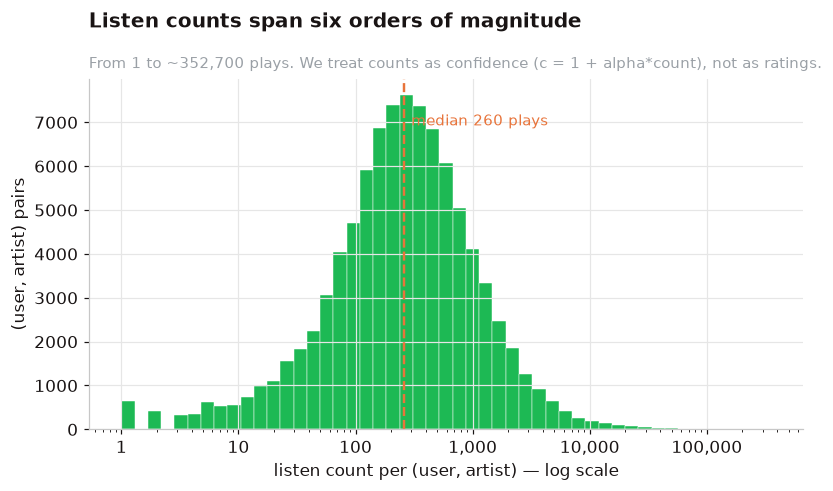

In [9]:
w = im.matrix.data
print(f'weight: min={w.min():.0f}, median={np.median(w):.0f}, mean={w.mean():.0f}, 99th pct={np.percentile(w,99):,.0f}, max={w.max():,.0f}')
_ = viz.plot_weight_distribution(w, save_path=FIG / 'weight_distribution.png')

## The tag landscape — a second signal for the long tail

Beyond listening, the dataset has user-applied **tags** (`user_taggedartists.dat`). These give a content signal that, unlike collaborative filtering, reaches artists with little co-listening — the basis for content-based cold start in notebook 06.

In [10]:
import pandas as pd
from src import content

ta = content.load_tag_assignments()  # [artistID, tagID]
tag_vals = pd.read_csv(project_root / 'data' / 'raw' / 'tags.dat',
                       sep='\t', encoding='latin-1').set_index('tagID')['tagValue']
n_tagged = ta['artistID'].nunique()
print(f"{len(ta):,} tag assignments | {ta['tagID'].nunique():,} distinct tags | "
      f"{n_tagged:,} artists tagged ({n_tagged/im.matrix.shape[1]*100:.0f}% of catalogue)")
print("\nmost-used tags:")
for tid, c in ta['tagID'].value_counts().head(10).items():
    print(f"  {str(tag_vals.get(tid, '?')):<22} {c:>6,}")

186,479 tag assignments | 9,749 distinct tags | 12,523 artists tagged (71% of catalogue)

most-used tags:
  rock                    7,503
  pop                     5,418
  alternative             5,251
  electronic              4,672
  indie                   4,458
  female vocalists        4,228
  80s                     2,791
  dance                   2,739
  alternative rock        2,631
  classic rock            2,287


Counts span from 1 to ~352,698. Treating these as graded ratings (RMSE) would chase magnitude, not preference rank. Instead we use them as **confidence** `c = 1 + alpha*count` in implicit ALS (`alpha` is a search knob).

## Findings → decisions

| Finding | Implication |
|---|---|
| Sparsity **99.72%**, but structural (top-50-per-user cap) | Not a learnability problem on the user side |
| Interactions/user capped at 50 (median 50) | Per-user holdout split is well-conditioned; **user cold start is tiny** (~8–21 thin users) |
| ~61% of artists have **1 listener** | Item long tail is the real constraint; caps recall; **popularity is a strong baseline** |
| Listen counts heavy-tailed (1 → 352k) | **Implicit** framing; confidence-weighted ALS; ranking metrics, not RMSE |

**On the FPD analogy:** the heavy stability-across-seeds/vintage machinery is **not** justified here (no imbalance, no time regime, ~18k macro-averaged test points). A **lightweight seed-sensitivity check** is. Full reasoning: [`docs/specs/sparsity_fragility_investigation.md`](../docs/specs/sparsity_fragility_investigation.md).

Next: **Milestone 2** — implement and toy-validate the frozen `eval_core.py` (per-user split + precision@k/recall@k/NDCG@k).